In [1]:
import json
import os
import numpy as np

cluster_path = os.path.join(os.getcwd(), "data", "query_hierarchical_clusters.jsonl")
all_query_clusters = []
with open(cluster_path, "r") as f:
    for line in f:
        all_query_clusters.append(json.loads(line))


In [2]:
import numpy as np

def calculate_blackbox_uncertainty_precomputed(row, presence_threshold=0.5):
    """
    Compute degree-based uncertainty using precomputed cluster data.

    Args:
        row: dict shaped like entries in query_hierarchical_clusters.jsonl/view.json.
             Must contain a "clusters" list, each with a "sequence_presence" array.
        presence_threshold: value above which a sequence is considered to contain the cluster.

    Returns:
        {
          "uncertainty": float,
          "confidence": list[float],  # per-sequence confidence = degree / num_sequences
          "degrees": list[float]      # row sums of the similarity matrix
        }
    """
    clusters = row.get("clusters", [])
    if not clusters:
        return {"uncertainty": 1.0, "confidence": [], "degrees": []}

    # Determine number of sequences
    num_seqs = len(row.get("sequence_ids", clusters[0].get("sequence_presence", [])))
    if num_seqs == 0:
        return {"uncertainty": 1.0, "confidence": [], "degrees": []}

    # Build sets of cluster indices per sequence using sequence_presence
    seq_sets = [set() for _ in range(num_seqs)]
    for c_idx, cluster in enumerate(clusters):
        pres = cluster.get("sequence_presence", [])
        for s_idx, p in enumerate(pres):
            if p > presence_threshold:
                seq_sets[s_idx].add(c_idx)

    # Jaccard similarity matrix
    W = np.zeros((num_seqs, num_seqs))
    for i in range(num_seqs):
        for j in range(num_seqs):
            set_i, set_j = seq_sets[i], seq_sets[j]
            if len(set_i) == 0 and len(set_j) == 0:
                W[i, j] = 1.0
            elif len(set_i) == 0 or len(set_j) == 0:
                W[i, j] = 0.0
            else:
                intersect = len(set_i.intersection(set_j))
                union = len(set_i.union(set_j))
                W[i, j] = intersect / union

    degrees = np.sum(W, axis=1)
    confidence_scores = degrees / num_seqs
    uncertainty_score = 1.0 - float(np.mean(confidence_scores))

    return {
        "uncertainty": uncertainty_score,
        "confidence": confidence_scores.tolist(),
        "sequence_ids": row["sequence_ids"],
        "degrees": degrees.tolist(),
    }



In [3]:
confidence_scores = []
uncertainty_scores = []
scores = []
for cluster in all_query_clusters:
    score = calculate_blackbox_uncertainty_precomputed(cluster)
    scores.append(score)
    confidence_scores.extend(score["confidence"])
    uncertainty_scores.append(score["uncertainty"])


3413
683


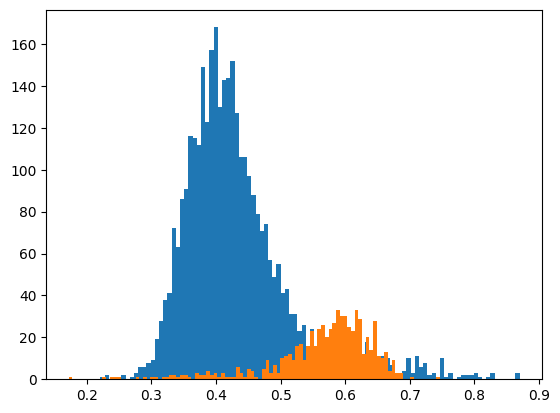

In [4]:
import matplotlib.pyplot as plt
print(len(confidence_scores))
print(len(uncertainty_scores))

plt.hist(confidence_scores, bins=100)
plt.hist(uncertainty_scores, bins=100)
plt.show()

In [5]:
results_path = os.path.join(os.getcwd(), "results", "black_box_results.jsonl")
with open(results_path, "w") as f:
    for score in scores:
        f.write(json.dumps(score) + "\n")

